# Experiment 3: Supervised Classification and Performance Assessment


Supervised learning is a branch of machine learning in which models are trained using labeled data to predict the class or output of unseen instances. Classification is one of the most common supervised learning tasks, where the objective is to assign input samples to one of several predefined categories based on their features. In this experiment, three widely used classification algorithms—Logistic Regression, Linear Discriminant Analysis (LDA), and k-Nearest Neighbors (k-NN)—are implemented and compared using the Iris dataset.

**Logistic Regression** is a statistical classification algorithm that estimates the probability of an input belonging to a particular class using the logistic (sigmoid) function. For multiclass problems, it employs multinomial logistic regression or the one-vs-rest approach. It is computationally efficient, interpretable, and performs well when the relationship between features and classes is approximately linear.

**Linear Discriminant Analysis (LDA)** is a supervised learning technique that assumes each class follows a Gaussian distribution with a common covariance matrix. It constructs linear decision boundaries by maximizing the separation between different classes while minimizing the variation within each class. Besides classification, LDA is also widely used for dimensionality reduction.

**k-Nearest Neighbors (k-NN)** is a non-parametric, instance-based learning algorithm that classifies a new sample based on the majority class among its *k* nearest neighbors. It relies on distance metrics such as Euclidean distance to measure similarity between samples. The choice of the value of *k* significantly influences the model's performance, making hyperparameter tuning an essential part of the algorithm.


## Algorithm

1. Import the required Python libraries for data preprocessing, model training, and evaluation.
2. Load the Iris dataset from the `sklearn.datasets` module.
3. Separate the dataset into feature variables (`X`) and target labels (`y`).
4. Standardize the feature values using `StandardScaler`.
5. Split the dataset into training and testing sets while preserving the class distribution.
6. Train a Logistic Regression classifier using the training dataset.
7. Predict the class labels for the testing dataset using the Logistic Regression model.
8. Train a Linear Discriminant Analysis (LDA) classifier using the training dataset.
9. Predict the class labels for the testing dataset using the LDA model.
10. Train a k-Nearest Neighbors (k-NN) classifier using the training dataset.
11. Predict the class labels for the testing dataset using the k-NN model.
12. Evaluate the performance of all three classifiers using classification accuracy.
13. Compare the performance of Logistic Regression, LDA, and k-NN classifiers.
14. Draw conclusions based on the obtained results.

## Task 1: Design and implement supervised classification models using Logistic Regression, Linear Discriminant Analysis (LDA), and k-Nearest Neighbors (k-NN)
*Suggested Dataset: Iris Dataset*


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from ml_utils import load_iris_split

# Load Iris, standardize features and create a stratified 80/20 split
X_train, X_test, y_train, y_test = load_iris_split(test_size=0.20, random_state=42)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

### Subtask 1.2: Implementing Multinomial Logistic Regression
**Concept:** Design, train, and evaluate a multinomial Logistic Regression classifier to establish a parametric baseline model.


In [ ]:
from sklearn.linear_model import LogisticRegression
from ml_utils import evaluate_model

# Multinomial Logistic Regression baseline
lr_model, lr_preds, lr_accuracy = evaluate_model(
    LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42),
    X_train, y_train, X_test, y_test, name="Logistic Regression"
)

### Subtask 1.3: Implementing Linear Discriminant Analysis (LDA)
**Concept:** Train a Linear Discriminant Analysis (LDA) classifier to observe how linear decision boundaries maximize the separation between different classes.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from ml_utils import evaluate_model

lda_model, lda_preds, lda_accuracy = evaluate_model(
    LinearDiscriminantAnalysis(), X_train, y_train, X_test, y_test, name="LDA"
)

### Subtask 1.4:  k-Nearest Neighbors (k-NN)
**Concept:** Train a k-NN classifier for classfication


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from ml_utils import evaluate_model

knn, y_pred_knn, knn_accuracy = evaluate_model(
    KNeighborsClassifier(), X_train, y_train, X_test, y_test, name="k-NN"
)

### Subtask 1.5: Performance Comparison of Linear vs. Distance-Based Classifiers
**Concept:** Compare and analyze the test accuracy and structural differences of the Logistic Regression, LDA, and optimized k-NN models.


In [ ]:
import pandas as pd

# Assemble performance metrics
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

print("--- Performance Comparison on Iris Dataset ---")
print(comparison_df.to_string(index=False))

## Task 2: Develop classification models using Naïve Bayes and Support Vector Machines (SVM) for complex classification tasks
*Suggested Dataset: Sonar Dataset*


### Subtask 2.1: Standard Scaling and High-Dimensional Data Splitting
**Concept:** Load the high-dimensional Sonar dataset, standardize the feature space, and perform a stratified split to prepare for binary classification.


In [ ]:
from ml_utils import load_sonar_split

# Load Sonar, standardize the 60 features and create a stratified 70/30 split
X_train_s, X_test_s, y_train_s, y_test_s = load_sonar_split(test_size=0.30, random_state=42)

print("Sonar Training Set Shape:", X_train_s.shape)
print("Sonar Test Set Shape:", X_test_s.shape)

### Subtask 2.2: Implementing Gaussian Naïve Bayes
**Concept:** Train a Gaussian Naïve Bayes classifier to establish a probabilistic baseline under class-conditional independence assumptions.


In [ ]:
from sklearn.naive_bayes import GaussianNB
from ml_utils import evaluate_model

nb_model, nb_preds, nb_accuracy = evaluate_model(
    GaussianNB(), X_train_s, y_train_s, X_test_s, y_test_s, name="Gaussian Naïve Bayes"
)

### Subtask 2.3: Implementing Linear Support Vector Machines (SVM)
**Concept:** Train a Support Vector Machine (SVM) classifier with a linear kernel to construct a maximum-margin linear decision hyperplane.


In [ ]:
from sklearn.svm import SVC
from ml_utils import evaluate_model

svm_linear, linear_preds, linear_accuracy = evaluate_model(
    SVC(kernel='linear', probability=True, random_state=42),
    X_train_s, y_train_s, X_test_s, y_test_s, name="Linear Kernel SVM"
)

In [ ]:
import pandas as pd

# Assemble performance metrics
sonar_comparison = pd.DataFrame({
    'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
    'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
})

print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")
print(sonar_comparison.to_string(index=False))

## Task 3: Analyze model performance using confusion matrix, precision, recall, F1-score, ROC analysis, and cross-validation techniques.

### Subtask 3.1: Plotting the Confusion Matrix Heatmap
**Concept:** Generate a confusion matrix to visualize true positives, false positives, true negatives, and false negatives in your classification results.


In [ ]:
from ml_utils import plot_confusion_matrix

# Confusion matrix for the Logistic Regression predictions
plot_confusion_matrix(
    y_test, lr_preds,
    labels=['Setosa', 'Versicolor', 'Virginica'],
    title="Confusion Matrix Heatmap"
)

### Subtask 3.2: Precision, Recall, F1-Score, and Support Analysis
**Concept:** Generate a detailed classification report to compute and analyze continuous performance metrics for both target classes.


In [ ]:
from ml_utils import print_classification_report

print_classification_report(
    y_test, lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica'],
    title="Logistic Regression Classification Report"
)

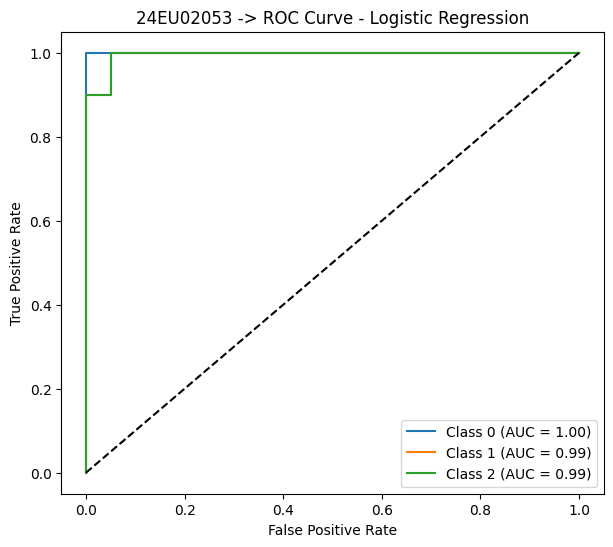

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# Re-initialize and fit lr_model to ensure it's fitted if this cell is run independently
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

# Convert test labels to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities
y_score = lr_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(7,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("24EU02053 -> ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

## Cross Validation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
from ml_utils import load_iris_scaled

# Load Iris and standardize the features
X_scaled, y = load_iris_scaled()

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=200)

# Perform 5-fold Cross Validation
cv_scores = cross_val_score(lr_model, X_scaled, y, cv=5, scoring='accuracy')

# Display results
print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))